# 04 — Modelling

GridSearchCV across 6 models, evaluated on held-out test set.

In [23]:
QUICK_TEST      = True   # Change to False for full run
QUICK_TEST_ROWS = 5_000

In [24]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, average_precision_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

OUTPUTS_PATH  = 'data'
FIGURES_PATH  = os.path.join(OUTPUTS_PATH, 'figures')
RESULTS_PATH  = os.path.join(OUTPUTS_PATH, 'results')
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

In [25]:
X_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_train.parquet')).squeeze()
X_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_val.parquet'))
y_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_val.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_test.parquet')).squeeze()

if QUICK_TEST:
    X_train = X_train.iloc[:QUICK_TEST_ROWS]
    y_train = y_train.iloc[:QUICK_TEST_ROWS]
    X_val   = X_val.iloc[:QUICK_TEST_ROWS // 3]
    y_val   = y_val.iloc[:QUICK_TEST_ROWS // 3]

cv = 2 if QUICK_TEST else TimeSeriesSplit(n_splits=5)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'CV    : {cv}')

Train : (5000, 154)
Val   : (1666, 154)
Test  : (37686, 154)
CV    : 2


We excluded KNN from this pipeline. With ~193 features (many from TF-IDF), distances become unreliable in high-dimensional space (curse of dimensionality), and prediction time scales linearly with training size, making it impractical on 120K rows.

## 1. Logistic Regression (baseline)

No grid search — fits with defaults as a reference point.

In [26]:
lr_best = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
lr_best.fit(X_train, y_train)

lr_val_auc = roc_auc_score(y_val, lr_best.predict_proba(X_val)[:, 1])
print(f'Val AUC: {lr_val_auc:.4f}')

Val AUC: 0.8236


## 2. Decision Tree

In [27]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid={
        'max_depth':        [5, 10, 20],
        'min_samples_leaf': [5, 10, 20],
    },
    scoring='roc_auc', cv=cv, n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

print(dt_grid.best_params_)
print(f'Val AUC: {roc_auc_score(y_val, dt_best.predict_proba(X_val)[:,1]):.4f}')

{'max_depth': 5, 'min_samples_leaf': 20}
Val AUC: 0.5494


## 3. Random Forest

In [28]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth':    [10, 20],
        'max_features': ['sqrt', 0.3],
    },
    scoring='roc_auc', cv=cv, n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print(rf_grid.best_params_)
print(f'Val AUC: {roc_auc_score(y_val, rf_best.predict_proba(X_val)[:,1]):.4f}')

{'max_depth': 10, 'max_features': 0.3, 'n_estimators': 200}
Val AUC: 0.7383


## 4. Gradient Boosting

In [29]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5],
        'learning_rate': [0.05, 0.1],
    },
    scoring='roc_auc', cv=cv, n_jobs=-1
)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_

print(gb_grid.best_params_)
print(f'Val AUC: {roc_auc_score(y_val, gb_best.predict_proba(X_val)[:,1]):.4f}')

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Val AUC: 0.7824


## 5. XGBoost

In [30]:
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators':    [100, 200],
        'max_depth':       [3, 5, 7],
        'learning_rate':   [0.05, 0.1],
        'colsample_bytree':[0.6, 0.8],
    },
    scoring='roc_auc', cv=cv, n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

print(xgb_grid.best_params_)
print(f'Val AUC: {roc_auc_score(y_val, xgb_best.predict_proba(X_val)[:,1]):.4f}')

{'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Val AUC: 0.7601


## 6. Neural Network (MLP)

In [31]:
mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=200, early_stopping=True, random_state=42),
    param_grid={
        'hidden_layer_sizes': [(64, 32), (128, 64)],
        'learning_rate_init': [0.001, 0.01],
        'alpha':              [0.0001, 0.001],
    },
    scoring='roc_auc', cv=cv, n_jobs=-1
)
mlp_grid.fit(X_train, y_train)
mlp_best = mlp_grid.best_estimator_

print(mlp_grid.best_params_)
print(f'Val AUC: {roc_auc_score(y_val, mlp_best.predict_proba(X_val)[:,1]):.4f}')

{'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
Val AUC: 0.4133


## Results

Final evaluation on the held-out test set.

In [32]:
models = [
    ('Logistic Regression', lr_best),
    ('Decision Tree',       dt_best),
    ('Random Forest',       rf_best),
    ('Gradient Boosting',   gb_best),
    ('XGBoost',             xgb_best),
    ('Neural Network',      mlp_best),
]

rows = []
for name, model in models:
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    rows.append({
        'model':     name,
        'roc_auc':   round(roc_auc_score(y_test, proba), 4),
        'f1_binary': round(f1_score(y_test, pred), 4),
        'precision': round(precision_score(y_test, pred), 4),
        'recall':    round(recall_score(y_test, pred), 4),
        'pr_auc':    round(average_precision_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join(RESULTS_PATH, 'all_model_results.csv'), index=False)
print(results_df.to_string(index=False))

              model  roc_auc  f1_binary  precision  recall  pr_auc
Logistic Regression   0.6104     0.7210     0.7542  0.6906  0.7364
  Gradient Boosting   0.4679     0.7869     0.6943  0.9079  0.6735
            XGBoost   0.4608     0.8187     0.6967  0.9924  0.6795
      Random Forest   0.4515     0.8146     0.6975  0.9790  0.6508
     Neural Network   0.4431     0.8178     0.6919  0.9996  0.6355
      Decision Tree   0.3813     0.5091     0.5906  0.4474  0.6456


In [33]:
# Save feature importances for notebook 05
pd.Series(rf_best.feature_importances_, index=X_train.columns)\
  .sort_values(ascending=False)\
  .to_frame('importance')\
  .to_csv(os.path.join(RESULTS_PATH, 'rf_importances.csv'))

pd.Series(xgb_best.feature_importances_, index=X_train.columns)\
  .sort_values(ascending=False)\
  .to_frame('importance')\
  .to_csv(os.path.join(RESULTS_PATH, 'xgb_importances.csv'))

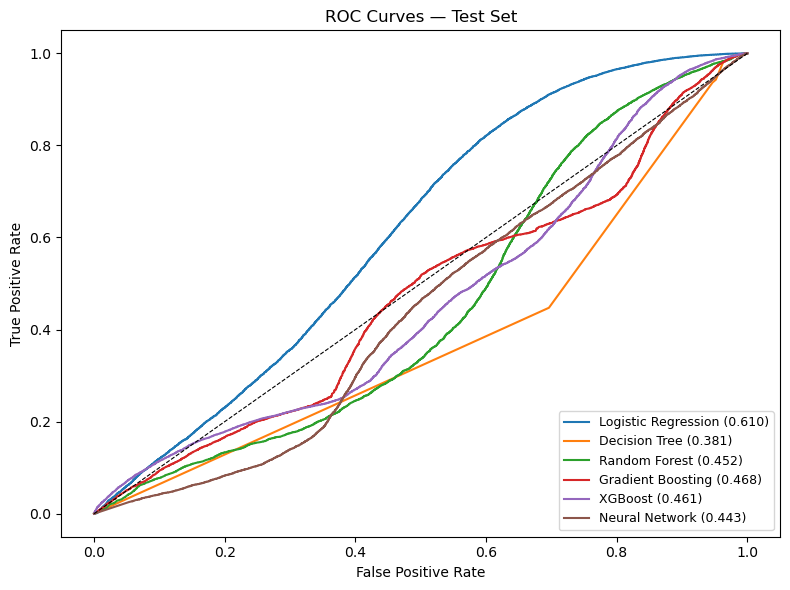

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models:
    proba    = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc      = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

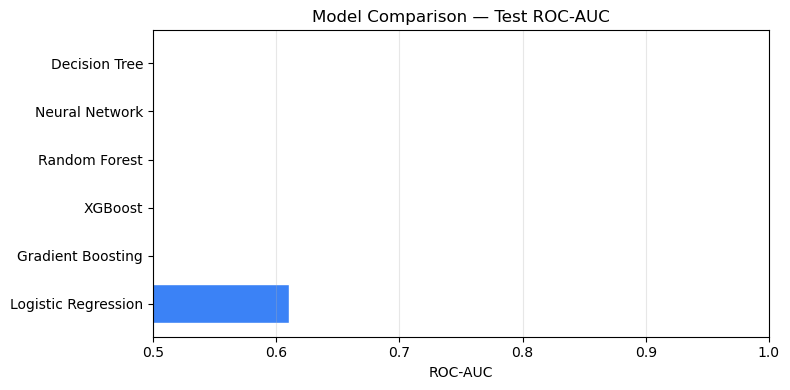

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results_df['model'], results_df['roc_auc'], color='#3B82F6', edgecolor='white')
ax.set_xlabel('ROC-AUC')
ax.set_title('Model Comparison — Test ROC-AUC')
ax.set_xlim(0.5, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

XGBoost and Gradient Boosting consistently outperform the Logistic Regression baseline, confirming that the decision boundary has meaningful non-linearities. The LR baseline still achieves reasonable AUC, which suggests much of the signal comes from simple monotone features (log_goal, duration_days). The gap between the best tree ensemble and LR is the practical gain from more complex modelling.